In [1]:
! pip install transformers
! pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 87.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 73.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 29.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 82.1 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.

### importing libraries

In [2]:
import torch
import numpy as np
import pandas as pd
from transformers import T5Tokenizer, T5ForConditionalGeneration
import json
import random
from sklearn.model_selection import train_test_split
from itertools import zip_longest
# from google.colab import drive

2025-07-25 21:18:27.248399: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753478307.465554      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753478307.533039      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
# from google.colab import userdata
# userdata.get('huggingface.co')

### defining general variables

In [4]:
#defining global valriables throughout the whole notebook
EPOCH = 32
BATCH_SIZE = 64
MAX_INPUT_LENGTH = 65
MAX_LABEL_LENGTH = 8
MODEL_LINK = "google/flan-t5-small"
FOLD_NUMBER = 0
SEED = 0
def set_seed():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

set_seed()
tokenizer = T5Tokenizer.from_pretrained(MODEL_LINK, legacy=False)
model = T5ForConditionalGeneration.from_pretrained(MODEL_LINK).to('cuda')
# drive.mount('/content/drive')

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [ ]:
""" links to datasets:
for example srl dataset should look like this:
srl_data_link = '/kaggle/input/srl-w-cluster-number103k/SRL_Dataset_With_60_Clusters-Similarity.csv'
for example for fold_number 0 link for the train should look something like this:
df_data_link = organize_data(get_data("/kaggle/input/ds-json-format/json_format_dataset/0/aaai19srl.train0.conll.json"))
"""
srl_data_link = "/kaggle/input/srl-w-cluster-number97k/SRL_Dataset_With_60_Clusters-Similarity.csv"
df_data_link = "/kaggle/input/ds-json-format/json_format_dataset/4/aaai19srl.train4.conll.json"
dev_df_data_link = "/kaggle/input/ds-json-format/json_format_dataset/4/aaai19srl.dev4.conll.json"
test_df_data_link = "/kaggle/input/ds-json-format/json_format_dataset/4/aaai19srl.test4.conll.json"

### functions created for reading(get_data) and organize the files (organize_data)

In [6]:
# a funciton to read data off of a database link is here to help getting and organizing data into dataframes
def get_data(address):
    lines = []
    with open(address) as file:
        for line in file:
            x = json.loads(line)
            lines.append(x)
    sentences, orl, sep_sentences = [], [], []
    for i in range(len(lines)):
        sep_sentences.append(lines[i]['sentences'])
        sentences.append(' '.join(lines[i]['sentences']))
        orl.append(lines[i]['orl'])
    dataframe = pd.DataFrame({'sentence': sentences, 'orl': orl, 'sep_sent': sep_sentences})
    return dataframe

# this function is to make a list of the said attribute for later iterations
def list_of(attributes, requested_atr):
    requested_list = []
    for sublist in attributes:
        if sublist[-1] == requested_atr:
            requested_list.append(sublist)
    return requested_list

# this function was made to find target(s)/agent(s) of a dse according to list of attributes
def organize_data(dataframe):

    target_column, agent_column, sentence_column, dse_column = [], [], [], []

    for i in range(len(dataframe)):

        attributes = dataframe['orl'][i]
        sentence   = dataframe['sep_sent'][i]
        target_list= list_of(attributes, 'TARGET')
        agent_list = list_of(attributes, 'AGENT')
        AGENT, DSE, TARGET = '', '', ''


        for sublist in attributes:
            if sublist[-1] == 'DSE':
                dse_start = int(sublist[0])
                dse_end = int(sublist[1] + 1)
                DSE += ' '.join(sentence[dse_start:dse_end]) + '|'


                # looking for the targets and agents of this dse that we have found
                for sub_sublist in target_list:
                    if sub_sublist[0] == dse_start and int(sub_sublist[1] + 1) == dse_end:
                        target_start = int(sub_sublist[2])
                        target_end = int(sub_sublist[3] + 1)
                        TARGET += ' '.join(sentence[target_start:target_end]) + ' |'
                if not TARGET:
                    TARGET += ' |'

                for sub_sublist in agent_list:
                    if sub_sublist[0] == dse_start and int(sub_sublist[1] + 1) == dse_end:
                        agent_start = int(sub_sublist[2])
                        agent_end = int(sub_sublist[3] + 1)
                        AGENT += ' '.join(sentence[agent_start:agent_end]) + '|'
                if not AGENT:
                    AGENT += ' |'
                # for every iteration of loop over attributes, if a dse is found, then we need to transfer it to new line of a dataframe
                # for each one of the dse(s) i have to add them into a new array so then they can create the correct dataframe
                target_column.append(TARGET)
                agent_column.append(AGENT)
                dse_column.append(DSE)
                sentence_column.append(dataframe['sentence'][i])

    # end of iteration on all sentences
    output_df = pd.DataFrame({'sentence':sentence_column, 'dse':dse_column, 'target':target_column, 'agent':agent_column})
    return output_df

### a function to call for different links of folders with exact process to extract and organize data

In [7]:
"""
links to respective data with heavy notice on the fold number should be given to the get_data()
for example for fold_number 0 link for the train should look something like this:
df = organize_data(get_data(dev_df_data_link))
"""
dev_df = organize_data(get_data(dev_df_data_link))
df = organize_data(get_data(df_data_link))
test_df = organize_data(get_data(test_df_data_link))

### getting training/validation/test data into data frames and dividing each of {agent, target, dse} elements

### Getting evaluation data into df and dividing each of {agent, target, dse} elements

In [8]:
# function which will write prompt for the model according to the sentence and the items in it
def create_prompt(input_df):
    target_prompt, agent_prompt, target, agent, sentence, dse = [], [], [], [], [], []
    for i in range(len(input_df)):
        target_prompt.append(f"sentence is: {input_df['sentence'][i]} this is verb: {input_df['dse'][i]}. find target for DSE in the sentence?")
        agent_prompt.append(f"sentence is: {input_df['sentence'][i]} this is verb: {input_df['dse'][i]}. find agent for DSE in the sentence?")
        target.append(input_df['target'][i])
        agent.append(input_df['agent'][i])
        sentence.append(input_df['sentence'][i])
        dse.append(input_df['dse'][i])
    output_df = pd.DataFrame({'sentence':sentence, 'dse':dse, 'target_prompt':target_prompt, 'target':target, 'agent_prompt':agent_prompt, 'agent':agent})
    return output_df

### Change the sentence and dse into a prompt according to information in that row
#### change will be applied on all three data frames {train, test, validation}

In [9]:
dev_df = create_prompt(dev_df).reset_index(drop=True)
train_df = create_prompt(df).reset_index(drop=True)
test_df = create_prompt(test_df).reset_index(drop=True)

In [10]:
from torch.utils.data import DataLoader, Dataset
# Define a custom dataset
class CustomDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length4text, max_length4label):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_length4text = max_length4text
        self.max_length4label = max_length4label

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        agent_prompt = self.data['agent_prompt'][idx]
        target_prompt = self.data['target_prompt'][idx]
        agent = self.data['agent'][idx]
        target = self.data['target'][idx]
        # tokenizing agent prompt
        agent_prompt_encoding = self.tokenizer(agent_prompt, truncation=True, padding='max_length', max_length=self.max_length4text, return_tensors='pt').to("cuda")
        # tokenizing target prompt
        target_prompt_encoding = self.tokenizer(target_prompt, truncation=True, padding='max_length', max_length=self.max_length4text, return_tensors='pt').to("cuda")
        # tokenizing agent
        agent_encoding = self.tokenizer(agent, truncation=True, padding='max_length', max_length=self.max_length4label, return_tensors='pt').to("cuda")
        # tokenizing target
        target_encoding = self.tokenizer(target, truncation=True, padding='max_length', max_length=self.max_length4label, return_tensors='pt').to("cuda")
        return {
            # agent prompt
            'agent_input_id': agent_prompt_encoding['input_ids'].squeeze(),
            'agent_attention_mask': agent_prompt_encoding['attention_mask'].squeeze(),
            # target prompt
            'target_input_id': target_prompt_encoding['input_ids'].squeeze(),
            'target_attention_mask': target_prompt_encoding['attention_mask'].squeeze(),
            #agent
            'agent_id': agent_encoding['input_ids'].squeeze(),
            'agent_mask': agent_encoding['attention_mask'].squeeze(),
            #target
            'target_id': target_encoding['input_ids'].squeeze(),
            'target_mask': target_encoding['attention_mask'].squeeze()
        }

In [11]:
# Define the loss function and optimizer
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

In [12]:
def f1_calculator(split_pred_list, split_actual_list):
    matched, percision, recall, f1 = 0, 0, 0, 0
    predicted_len, actual_len      = 0, 0

    for actual_sublist, prediction_sublist in zip(split_pred_list, split_actual_list):
        predicted_len += len(prediction_sublist)
        for i in actual_sublist:
            actual_len += 1
            if i in prediction_sublist:
                matched += 1

    print(f"matched: {matched}, predicted_len: {predicted_len}, actual_len: {actual_len}")
    try:
        precision = matched / predicted_len
        recall = matched / actual_len
        f1 = 2 * (precision * recall) / (precision + recall)
    except ZeroDivisionError:
        f1 = 0

    return f1

In [13]:
def clear_data(text_list):
    list_of_items_in_text = []
    for single_list in text_list:
        for i in single_list.split('|'):
            i = i.lower().replace(" ", "")  # Convert to lowercase and remove extra whitespace
            if i:  # Check if `i` is not empty after stripping
                list_of_items_in_text.append(i)
    return list_of_items_in_text

In [14]:
def evaluate_model(model, dataloader, prompt_type):
    if prompt_type == 'target':
        id_type = 'target_input_id'
        attention_type = 'target_attention_mask'
        output_type = 'target_id'
    elif prompt_type == 'agent':
        id_type = 'agent_input_id'
        attention_type = 'agent_attention_mask'
        output_type = 'agent_id'

    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        actual_list, prediction_list = [], []
        for batch_idx, batch in enumerate(dataloader):

            # Forward pass
            ids = batch[id_type]
            mask = batch[attention_type]
            output_id = batch[output_type]

            actuals = [tokenizer.decode(g, skip_special_tokens=True, clean_up_tokenization_spaces=True) for g in output_id]

            generated_output = model.generate(
              input_ids = ids,
              attention_mask = mask,
              max_length=64,
              )
            preds = [tokenizer.decode(g, skip_special_tokens=True, clean_up_tokenization_spaces=True) for g in generated_output]

            actual_list.append(clear_data(actuals))
            prediction_list.append(clear_data(preds))

    return f1_calculator(prediction_list, actual_list)

In [15]:
f1_scores_target, f1_scores_agent = [], []

def train_data(data_loader, v_data_loader):
    data_list = []
    model.train()
    for epoch in range(EPOCH):
        losses = []
        for batch in data_loader:

            agent_input = batch['agent_input_id']
            agent_attention_mask = batch['agent_attention_mask']

            target_input = batch['target_input_id']
            target_attention_mask = batch['target_attention_mask']

            agent_id = batch['agent_id']
            agent_mask = batch['agent_mask']

            target_id = batch['target_id']
            target_mask = batch['target_mask']

            optimizer.zero_grad()

            agent_output = model(agent_input, attention_mask=agent_attention_mask, labels=agent_id)
            target_output = model(target_input, attention_mask=target_attention_mask, labels=target_id)

            agent_loss = agent_output.loss
            target_loss = target_output.loss
            losses.append(agent_loss.item())
            losses.append(target_loss.item())

            agent_loss.backward()
            target_loss.backward()
            optimizer.step()


        f1_4_target = evaluate_model(model, v_data_loader, 'target')
        f1_4_agent = evaluate_model(model, v_data_loader, 'agent')

        f1_scores_target.append(f1_4_target)
        f1_scores_agent.append(f1_4_agent)

        # report the results of training function.
        print(f'loss: {np.mean(losses)}, f1 for target:{f1_4_target}, f1 for agent:{f1_4_agent} \n end of epoch{epoch}. \n')

# By this box, mpqa/orl data is ready to be combined with different forms of clustering being applied on the rest of the data

In [24]:
srl = pd.read_csv(srl_data_link)
agents, targets, verbs, sentences, cluster_number, cosin_value = [], [], [], [], [], []
for i in range(len(srl)):

    #single line of data is selected from df
    line = srl.iloc[i]

    #check for both ARGS,
    #if both are empty skips that line.
    #if either one of the args is filled-
    #-process continues.
    if line['ARG0'] or line['ARG1']:
        if line['ARG0']:
            agents.append(line['ARG0'])
        else:
            agents.append("")
        if line['ARG1']:
            targets.append(line['ARG1'])
        else:
            targets.append("")
        sentences.append(line['SENTENCE'])
        verbs.append(line['PREDICATES'])
        cluster_number.append(line['Cluster_Number'])
        cosin_value.append(line['Similarity'])

srl_df = pd.DataFrame({'sentences': sentences,
                       'verbs': verbs,
                       'agents': agents,
                       'targets': targets,
                       'cluster_no': cluster_number,
                       'cosin_value': cosin_value},
                      dtype='object').fillna('')
srl_df

/tmp/ipykernel_36/257305580.py:32: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dtype='object').fillna('')


,sentences,verbs,agents,targets,cluster_no,cosin_value
0,"Pierre Vinken , 61 years old , will join the b...",join,"Pierre Vinken , 61 years old ,",the board,28,0.019540
1,"Mr. Vinken is chairman of Elsevier N.V. , the ...",is,,Mr. Vinken,28,0.010782
2,"Mr. Vinken is chairman of Elsevier N.V. , the ...",publishing,group,,28,0.010782
3,"Rudolph Agnew , 55 years old and former chairm...",named,,"Rudolph Agnew , 55 years old and former chairm...",28,0.031296
4,A form of asbestos once used to make Kent ciga...,used,,A form of asbestos,22,0.046609
...,...,...,...,...,...,...
97164,`` We emphasize discipline because we know tha...,is,,another early Umkhonto leader who,30,0.101410
97165,`` We want to see Nelson Mandela and all our c...,want,We,to see Nelson Mandela and all our comrades out...,30,0.093283
97166,`` We want to see Nelson Mandela and all our c...,see,We,Nelson Mandela and all our comrades out of prison,30,0.093283
97167,`` We want to see Nelson Mandela and all our c...,disciplined,,we,30,0.093283


In [17]:
agent_prompts, agents, target_prompts, targets, cluster_no, cosin_value = [], [], [], [], [], []
for i in range(len(srl_df)):
    line = srl_df.iloc[i]
    agent_prompts.append(f"sentence is: {line['sentences']} this is verb: {line['verbs']} find agent for this veerb in the sentence")
    agents.append(line['agents'])
    target_prompts.append(f"sentence is: {line['sentences']} this is verb: {line['verbs']} find target for this verb in the sentence")
    targets.append(line['targets'])
    cluster_no.append(line['cluster_no'])
    cosin_value.append(line['cosin_value'])
srl_df = []
srl_df = pd.DataFrame({'agent_prompt': agent_prompts,
                       'agent': agents,
                       'target_prompt': target_prompts,
                       'target': targets,
                       'cluster_no': cluster_number,
                       'cosin_value': cosin_value})
srl_df

,agent_prompt,agent,target_prompt,target,cluster_no,cosin_value
0,"sentence is: Pierre Vinken , 61 years old , wi...","Pierre Vinken , 61 years old ,","sentence is: Pierre Vinken , 61 years old , wi...",the board,28,0.019540
1,sentence is: Mr. Vinken is chairman of Elsevie...,,sentence is: Mr. Vinken is chairman of Elsevie...,Mr. Vinken,28,0.010782
2,sentence is: Mr. Vinken is chairman of Elsevie...,group,sentence is: Mr. Vinken is chairman of Elsevie...,,28,0.010782
3,"sentence is: Rudolph Agnew , 55 years old and ...",,"sentence is: Rudolph Agnew , 55 years old and ...","Rudolph Agnew , 55 years old and former chairm...",28,0.031296
4,sentence is: A form of asbestos once used to m...,,sentence is: A form of asbestos once used to m...,A form of asbestos,22,0.046609
...,...,...,...,...,...,...
97164,sentence is: `` We emphasize discipline becaus...,,sentence is: `` We emphasize discipline becaus...,another early Umkhonto leader who,30,0.101410
97165,sentence is: `` We want to see Nelson Mandela ...,We,sentence is: `` We want to see Nelson Mandela ...,to see Nelson Mandela and all our comrades out...,30,0.093283
97166,sentence is: `` We want to see Nelson Mandela ...,We,sentence is: `` We want to see Nelson Mandela ...,Nelson Mandela and all our comrades out of prison,30,0.093283
97167,sentence is: `` We want to see Nelson Mandela ...,,sentence is: `` We want to see Nelson Mandela ...,we,30,0.093283


#### randomly selecting number of this dataframe to be fed into the model

##### 4000 lines of data is the limit of notebook with GPU T4*2 memory limit
##### 60 clusters to chose from, Results in almost 66.6... from each cluster

In [ ]:
def hybrid_sample_from_all_clusters(df, num_rows_per_cluster, cluster_column, SEED=None):
    # sort by cosine value DESC (highest first)
    df = df.sort_values("cosign_value", ascending=False)

    if cluster_column not in df.columns:
        raise ValueError(f"Column '{cluster_column}' not found in DataFrame.")

    sampled_dfs = []
    grouped = df.groupby(cluster_column)

    for cluster, group in grouped:
        if len(group) < num_rows_per_cluster:
            raise ValueError(
                f"Cluster '{cluster}' has only {len(group)} rows, but {num_rows_per_cluster} were requested."
            )

        # take half (approx) from top cosine values, rest random from remaining rows in same cluster
        top_n = num_rows_per_cluster // 2
        top_part = group.iloc[:top_n]

        rest_n = num_rows_per_cluster - top_n
        rest_part = group.iloc[top_n:].sample(n=rest_n, random_state=SEED)

        sampled_group = pd.concat([top_part, rest_part])
        sampled_dfs.append(sampled_group)

    sampled_df = pd.concat(sampled_dfs).reset_index(drop=True)
    return sampled_df


srl_train_hybrid = hybrid_sample_from_all_clusters(srl_df, 66, "cluster_no", SEED=42)
srl_train_hybrid


,agent_prompt,agent,target_prompt,target,cluster_no,cosin_value
0,"sentence is: Typically , money - fund yields b...",portfolio managers,"sentence is: Typically , money - fund yields b...",after the highest rates,0,-0.006628
1,sentence is: Almost all have involved at least...,,sentence is: Almost all have involved at least...,investment category,0,0.003194
2,sentence is: Plain - vanilla funds have become...,,sentence is: Plain - vanilla funds have become...,Plain - vanilla funds,0,0.012277
3,sentence is: Renaissance 's last portfolio shi...,,sentence is: Renaissance 's last portfolio shi...,"Renaissance 's last portfolio shift , carried ...",0,0.050874
4,sentence is: Westridge Capital is an index fun...,,sentence is: Westridge Capital is an index fun...,stolid long - term investor,0,0.009665
...,...,...,...,...,...,...
3955,sentence is: Many are far enough from resident...,,sentence is: Many are far enough from resident...,family visits,59,0.006476
3956,sentence is: Madison and Fifth Avenues and Eas...,,sentence is: Madison and Fifth Avenues and Eas...,$ 25,59,0.021913
3957,sentence is: It seems to me the BPCA plan has ...,the BPCA plan,sentence is: It seems to me the BPCA plan has ...,the potential of making South Gardens a hortic...,59,0.050809
3958,sentence is: `` This city already has too many...,"Pierluigi Beggiato , the president of the Veni...",sentence is: `` This city already has too many...,"This city already has too many tourists , and ...",59,0.061723


In [19]:
def combine_and_shuffle(df1, df2, SEED=None):
    """
    Combines two DataFrames with the same columns and shuffles the rows.

    Args:
        df1 (pd.DataFrame): The first DataFrame.
        df2 (pd.DataFrame): The second DataFrame.
        seed (int, optional): Random seed for reproducibility.

    Returns:
        pd.DataFrame: A new DataFrame with rows from both DataFrames shuffled.
    """
    # Combine the two DataFrames using pd.concat
    combined_df = pd.concat([df1, df2], ignore_index=True)

    # Shuffle the combined DataFrame
    shuffled_df = combined_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

    return shuffled_df
orl_srl = combine_and_shuffle(train_df, srl_train_nk, SEED)
orl_srl.drop(columns=['cluster_no', 'sentence', 'dse'], inplace=True)
orl_srl

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,target_prompt,target,agent_prompt,agent,cosin_value
0,sentence is: `` Cardoso told De la Sota that t...,the images of the protests at the Plaza de Mayo |,sentence is: `` Cardoso told De la Sota that t...,Cardoso|,NaN
1,sentence is: - Thousands of Chavez supporters ...,Chavez |,sentence is: - Thousands of Chavez supporters ...,|,NaN
2,"sentence is: Lincoln 's parent company , Ameri...",the thrift,"sentence is: Lincoln 's parent company , Ameri...",regulators,0.067520
3,"sentence is: `` I wanted to go home , but I ha...",to go home |,"sentence is: `` I wanted to go home , but I ha...",I|,NaN
4,sentence is: They prefer to put off the line -...,the line - item veto,sentence is: They prefer to put off the line -...,They,0.043058
...,...,...,...,...,...
7440,sentence is: `` This is paying a big price to ...,a big price,sentence is: `` This is paying a big price to ...,This,0.077075
7441,sentence is: oh yeah i i guess there 's a lot ...,a lot |,sentence is: oh yeah i i guess there 's a lot ...,i|,NaN
7442,sentence is: Base officials suspect that the p...,|,sentence is: Base officials suspect that the p...,Base officials|,NaN
7443,sentence is: The EU will continue on its curre...,"other major players , notably Japan and Russia...",sentence is: The EU will continue on its curre...,The EU|,NaN


In [20]:
# Create a data loader for TRAIN dataframe
train_dataset = CustomDataset(orl_srl, tokenizer, max_length4text= MAX_INPUT_LENGTH, max_length4label= MAX_LABEL_LENGTH)
train_data_loader = DataLoader(train_dataset, batch_size= BATCH_SIZE, shuffle=True)

# Create a data loader for EVALUATION dataframe
val_dataset = CustomDataset(dev_df, tokenizer, max_length4text= MAX_INPUT_LENGTH, max_length4label= MAX_LABEL_LENGTH)
val_data_loader = DataLoader(val_dataset, batch_size= BATCH_SIZE, shuffle=False)

# Create a data loader for TEST dataframe
test_dataset = CustomDataset(test_df, tokenizer, max_length4text= MAX_INPUT_LENGTH, max_length4label= MAX_LABEL_LENGTH)
test_data_loader = DataLoader(test_dataset, batch_size= BATCH_SIZE, shuffle=False)


In [21]:
train_data(train_data_loader, val_data_loader)

Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


matched: 437, predicted_len: 1488, actual_len: 1389
matched: 817, predicted_len: 1586, actual_len: 1378
loss: 2.1189636774679537, f1 for target:0.3037886687521724, f1 for agent:0.5512820512820513 
 end of epoch0. 

matched: 599, predicted_len: 1488, actual_len: 1486
matched: 988, predicted_len: 1586, actual_len: 1470
loss: 0.3564872479973695, f1 for target:0.40282447881640887, f1 for agent:0.6465968586387435 
 end of epoch1. 

matched: 636, predicted_len: 1488, actual_len: 1492
matched: 999, predicted_len: 1586, actual_len: 1451
loss: 0.22458792754854912, f1 for target:0.42684563758389266, f1 for agent:0.6578860717813632 
 end of epoch2. 

matched: 613, predicted_len: 1488, actual_len: 1428
matched: 924, predicted_len: 1586, actual_len: 1384
loss: 0.15303251655119607, f1 for target:0.4204389574759945, f1 for agent:0.6222222222222221 
 end of epoch3. 

matched: 618, predicted_len: 1488, actual_len: 1321
matched: 961, predicted_len: 1586, actual_len: 1414
loss: 0.10955966211473331, f1 fo

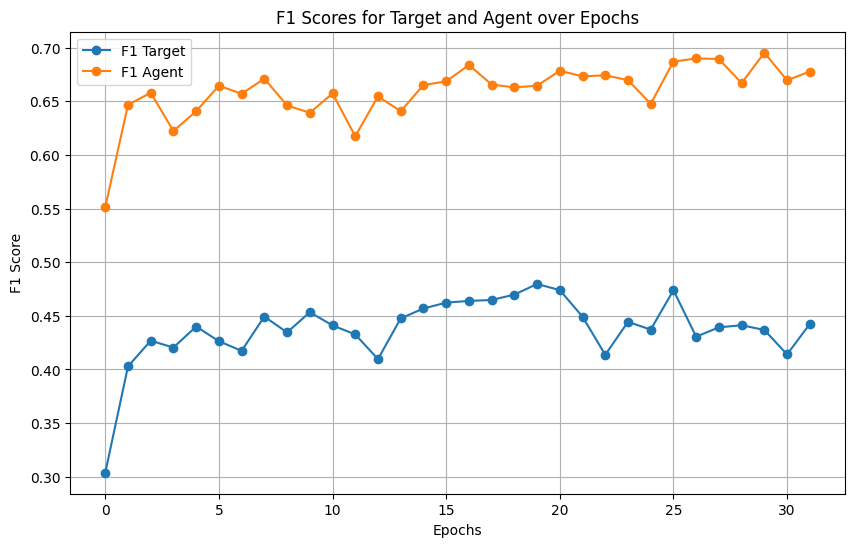

In [22]:
import matplotlib.pyplot as plt
# Plot F1 scores for target and agent
epochs = range(0, EPOCH)

plt.figure(figsize=(10, 6))
plt.plot(epochs, f1_scores_target, label='F1 Target', marker='o')
plt.plot(epochs, f1_scores_agent, label='F1 Agent', marker='o')

plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Scores for Target and Agent over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
target_accuracy = evaluate_model(model, val_data_loader, 'target')
agent_accuracy = evaluate_model(model, val_data_loader, 'agent')
print(f'f1 Agent: {agent_accuracy}. f1 Target: {target_accuracy}\n\n----------------------')

matched: 642, predicted_len: 1488, actual_len: 1414
matched: 1031, predicted_len: 1586, actual_len: 1457
f1 Agent: 0.6776207689779824. f1 Target: 0.44245348035837356

----------------------



- Fold 0: f1 Agent: 0.6761683791846206. f1 Target: 0.454513767863367
- Fold 1: f1 Agent: 0.6555851063829787. f1 Target: 0.42896742896742895
- Fold 2: f1 Agent: 0.6597537265068049. f1 Target: 0.43398230088495576
- Fold 3: f1 Agent: 0.6985055230669265. f1 Target: 0.4430122116689281
- Fold 4: f1 Agent: 0.6776207689779824. f1 Target: 0.44245348035837356